# 02 — Data Cleaning & QC Pipeline

Continuation of `01_dataset_understanding.ipynb`.  
Implements the cleaning plan from Section 16 in strict leakage-safe order:

| Step | Section |
|------|---------|
| Schema validation & key integrity | §2 |
| Missingness quantification + `_isnan` flags | §3 |
| Column pruning (near-zero-variance V-features) | §4 |
| Feature engineering (time, card aggregates, `has_identity`) | §5 |
| Categorical encoding (by cardinality) | §6 |
| Time-based train / validation split — **last** | §7 |
| QC summary & persist outputs | §8 |

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

DATA   = Path('../data/raw/')
OUTPUT = Path('../data/processed/')
OUTPUT.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')
print(f'Output directory: {OUTPUT.resolve()}')

Libraries loaded.
Output directory: D:\banking-risk-intelligence-rag\data\processed


## 2. Load & Schema Validation

In [2]:
trn = pd.read_csv(DATA / 'train_transaction.csv')
idn = pd.read_csv(DATA / 'train_identity.csv')

print(f'Transaction : {trn.shape[0]:,} rows x {trn.shape[1]} cols')
print(f'Identity    : {idn.shape[0]:,} rows x {idn.shape[1]} cols')

Transaction : 590,540 rows x 394 cols
Identity    : 144,233 rows x 41 cols


In [3]:
# Key integrity checks — these should all pass silently
assert trn['TransactionID'].is_unique, 'TransactionID not unique in transaction table'
assert idn['TransactionID'].is_unique, 'TransactionID not unique in identity table'
assert idn['TransactionID'].isin(trn['TransactionID']).all(), \
    'Identity table contains IDs absent from transaction table'
assert trn['isFraud'].isnull().sum() == 0, 'isFraud contains NaN'
assert set(trn['isFraud'].unique()) == {0, 1}, 'isFraud has values other than 0/1'

is_sorted = trn['TransactionDT'].is_monotonic_increasing
print(f'TransactionDT monotonically increasing : {is_sorted}')
print('All key integrity checks passed.')

TransactionDT monotonically increasing : True
All key integrity checks passed.


In [4]:
# Left-join — keep all 590k transactions
df = trn.merge(idn, on='TransactionID', how='left')
print(f'Merged table : {df.shape[0]:,} rows x {df.shape[1]} cols')

# Column group index — used throughout the notebook
GROUPS = {
    'C':    [c for c in df.columns if c.startswith('C') and c[1:].isdigit()],
    'D':    [c for c in df.columns if c.startswith('D') and c[1:].isdigit()],
    'M':    [c for c in df.columns if c.startswith('M') and c[1:].isdigit()],
    'V':    [c for c in df.columns if c.startswith('V') and c[1:].isdigit()],
    'card': [c for c in df.columns if c.startswith('card')],
    'addr': [c for c in df.columns if c.startswith('addr')],
    'id_':  [c for c in df.columns if c.startswith('id_')],
}

print('Column group sizes:')
for g, cols in GROUPS.items():
    print(f'  {g:<6}: {len(cols):>3} features')

Merged table : 590,540 rows x 434 cols
Column group sizes:
  C     :  14 features
  D     :  15 features
  M     :   9 features
  V     : 339 features
  card  :   6 features
  addr  :   2 features
  id_   :  38 features


## 3. Missingness Quantification & `_isnan` Indicator Flags

Missingness here is **MNAR** — V-feature sub-blocks drop out together and the identity
table covers only ~24% of rows by design.  
**Tree branch**: NaNs left in place; `_isnan` flags added where the gap carries signal.  
**Linear branch**: median-imputed numerics + explicit `'missing'` level for categoricals (§6).

Columns with any missing : 414 / 434
  > 90% missing          : 12
  > 50% missing          : 214
  > 10% missing          : 322


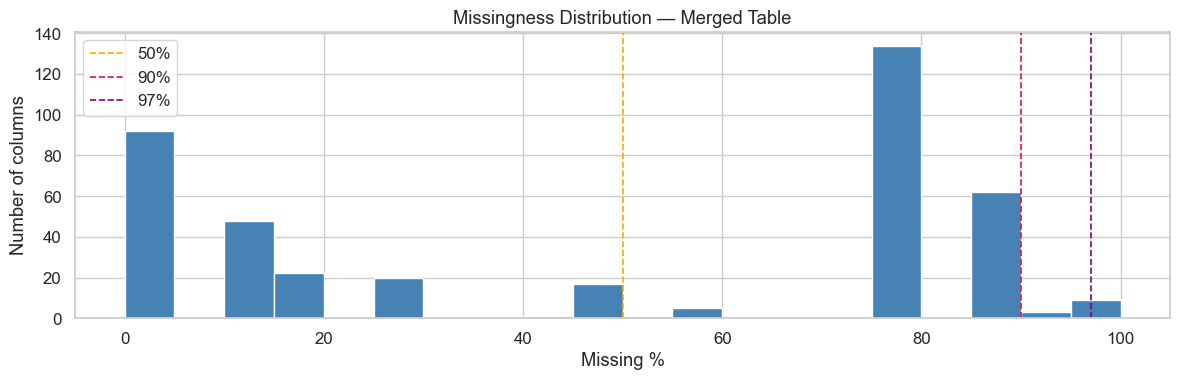

In [5]:
miss_pct = df.isnull().mean().mul(100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

print(f'Columns with any missing : {len(miss_pct)} / {df.shape[1]}')
print(f'  > 90% missing          : {(miss_pct > 90).sum()}')
print(f'  > 50% missing          : {(miss_pct > 50).sum()}')
print(f'  > 10% missing          : {(miss_pct > 10).sum()}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(miss_pct.values, bins=np.arange(0, 105, 5), color='steelblue', edgecolor='white')
ax.axvline(50, color='orange', ls='--', lw=1.2, label='50%')
ax.axvline(90, color='crimson', ls='--', lw=1.2, label='90%')
ax.axvline(97, color='purple',  ls='--', lw=1.2, label='97%')
ax.set_xlabel('Missing %')
ax.set_ylabel('Number of columns')
ax.set_title('Missingness Distribution — Merged Table')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Verify co-missingness structure in V-features (MNAR sanity check)
v_cols = GROUPS['V']
v_pattern = df[v_cols].isnull().astype(int)
n_patterns = v_pattern.drop_duplicates().shape[0]
print(f'Distinct missingness patterns across {len(v_cols)} V-features: {n_patterns}')
print('(A small count confirms block-wise MNAR — missing is a meaningful signal)')

Distinct missingness patterns across 339 V-features: 237
(A small count confirms block-wise MNAR — missing is a meaningful signal)


In [7]:
# Add _isnan indicator flags for numeric columns with 5%–97% missingness.
# Below 5%: too rare to matter. Above 97%: column is effectively dead (dropped in §4).
FLAG_LOWER, FLAG_UPPER = 5.0, 97.0

cols_to_flag = [
    c for c in miss_pct.index
    if FLAG_LOWER <= miss_pct[c] <= FLAG_UPPER and df[c].dtype != object
]
print(f'Numeric columns that will get _isnan flags: {len(cols_to_flag)}')

isnan_df = df[cols_to_flag].isnull().astype(np.int8)
isnan_df.columns = [c + '_isnan' for c in cols_to_flag]
df = pd.concat([df, isnan_df], axis=1)

print(f'df shape after adding isnan flags: {df.shape}')

Numeric columns that will get _isnan flags: 287
df shape after adding isnan flags: (590540, 721)


## 4. Column Pruning — Near-Zero-Variance V-Features

Drop V-features where `std < 0.01` (essentially constant on non-null rows).  
Also drop columns >97% missing on the merged table — these are dead after the join  
(`id_23` and `id_27` qualify here). Their `_isnan` flags were already captured in §3.

In [8]:
NZV_THRESHOLD = 0.01

v_stds   = df[v_cols].std()
nzv_cols = v_stds[v_stds < NZV_THRESHOLD].index.tolist()
print(f'Near-zero-variance V-features (std < {NZV_THRESHOLD}): {len(nzv_cols)}')

dead_cols = miss_pct[miss_pct > 97].index.tolist()
print(f'Columns >97% missing on merged table  : {len(dead_cols)}')
if dead_cols:
    print(' ', dead_cols)

DROP_COLS = list(set(nzv_cols + dead_cols) - {'isFraud', 'TransactionID'})
print(f'Total columns to drop: {len(DROP_COLS)}')

df.drop(columns=DROP_COLS, inplace=True, errors='ignore')
print(f'df shape after pruning: {df.shape}')

Near-zero-variance V-features (std < 0.01): 2
Columns >97% missing on merged table  : 9
  ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22']
Total columns to drop: 11
df shape after pruning: (590540, 710)


## 5. Feature Engineering

| Feature | Branch | Rationale |
|---------|--------|-----------|
| `hour_of_day`, `day_of_week` | Both | Fraud rate varies by time of day (EDA §8) |
| `sin_hour`, `cos_hour`, `sin_dow`, `cos_dow` | Linear only | Cyclic wrap (23→0) |
| `has_identity` | Both | Identity presence triples fraud rate (EDA §10) |
| `card1_txn_count`, `card1_mean_amt` | Both | Aggregate over card entity |

> **Leakage note**: card aggregates are computed on the full training set here for inspection.
> In cross-validation they must be recomputed on each fold's training portion only.

In [9]:
# Time features
df['hour_of_day'] = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // 86400) % 7
df['sin_hour']    = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['cos_hour']    = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['sin_dow']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_dow']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

# has_identity
id_cols_present = [c for c in GROUPS['id_'] if c in df.columns]
df['has_identity'] = df[id_cols_present].notnull().any(axis=1).astype(np.int8)

# card1 entity aggregates
card1_agg = (
    df.groupby('card1')['TransactionAmt']
      .agg(card1_txn_count='count', card1_mean_amt='mean')
      .reset_index()
)
df = df.merge(card1_agg, on='card1', how='left')

print('Engineered features added.')
print(df[['hour_of_day', 'day_of_week', 'has_identity',
          'card1_txn_count', 'card1_mean_amt']].describe().T.to_string())

Engineered features added.
                      count      mean       std    min      25%      50%       75%        max
hour_of_day     590540.0000   13.8619    7.6072 0.0000   6.0000  16.0000   20.0000    23.0000
day_of_week     590540.0000    2.9579    2.0340 0.0000   1.0000   3.0000    5.0000     6.0000
has_identity    590540.0000    0.2442    0.4296 0.0000   0.0000   0.0000    0.0000     1.0000
card1_txn_count 590540.0000 2528.8155 3702.6555 1.0000 132.0000 919.0000 3152.0000 14932.0000
card1_mean_amt  590540.0000  135.0272   79.2833 0.6150  97.8638 120.2093  157.0494  3454.9500


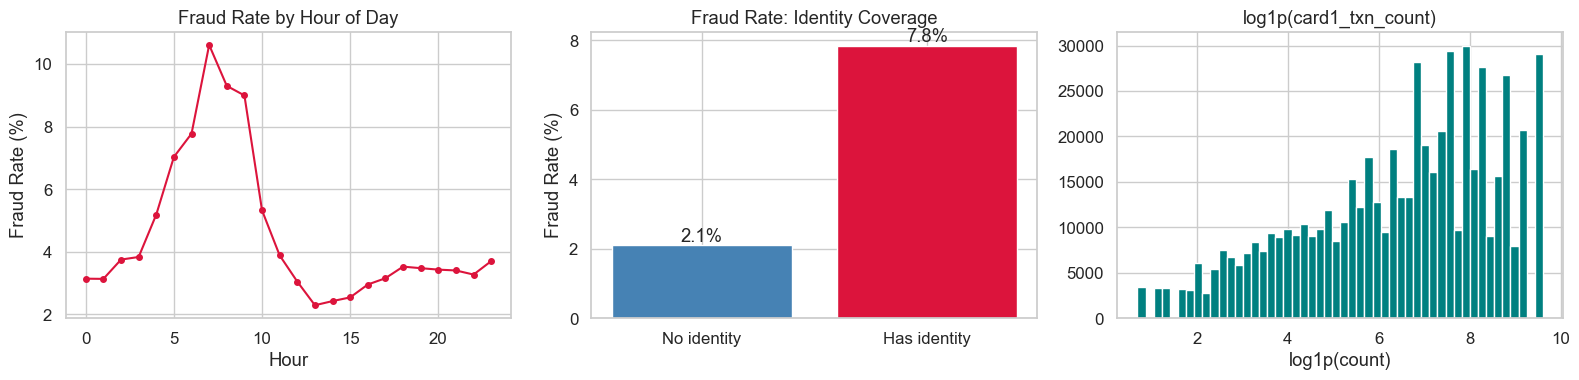

In [10]:
# Sanity check: do the new features carry the expected signal?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# hour_of_day vs fraud rate
hr = df.groupby('hour_of_day')['isFraud'].mean() * 100
axes[0].plot(hr.index, hr.values, marker='o', ms=4, color='crimson')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate (%)')

# has_identity vs fraud rate
hi = df.groupby('has_identity')['isFraud'].mean() * 100
axes[1].bar(['No identity', 'Has identity'], hi.values,
            color=['steelblue', 'crimson'])
axes[1].set_title('Fraud Rate: Identity Coverage')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(hi.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center')

# card1_txn_count distribution (log scale)
axes[2].hist(np.log1p(df['card1_txn_count'].dropna()), bins=50,
             color='teal', edgecolor='white')
axes[2].set_title('log1p(card1_txn_count)')
axes[2].set_xlabel('log1p(count)')

plt.tight_layout()
plt.show()

## 6. Categorical Encoding

| Cardinality | Columns | Tree branch | Linear branch |
|-------------|---------|-------------|---------------|
| Low (≤10) | `ProductCD`, `card4`, `card6`, `M1`–`M9`, binary `id_` flags | Label encode | One-hot |
| Medium (11–200) | `P_emaildomain`, `card3`, `card5`, `id_30`, `id_31`, `id_34`, `DeviceType` | Frequency encode | Frequency encode |
| High (>200) | `R_emaildomain`, `id_33`, `DeviceInfo` | Frequency encode | Frequency encode |

M-flags treated as **plain categoricals** (T / F / NaN).  
`card1` treated as entity identifier — already aggregated in §5, not encoded directly.

In [11]:
cat_cols = [c for c in df.columns if df[c].dtype == object]
print(f'Categorical columns remaining: {len(cat_cols)}')

card_report = pd.DataFrame({
    'cardinality': {c: df[c].nunique() for c in cat_cols},
    'missing_pct': {c: df[c].isnull().mean() * 100 for c in cat_cols},
}).sort_values('cardinality')
print(card_report.to_string())

Categorical columns remaining: 29
               cardinality  missing_pct
M2                       2      45.9071
M3                       2      45.9071
M1                       2      45.9071
id_12                    2      75.5761
M8                       2      58.6331
M7                       2      58.6353
M6                       2      28.6788
M5                       2      59.3494
M9                       2      58.6331
id_37                    2      76.1261
id_38                    2      76.1261
DeviceType               2      76.1557
id_35                    2      76.1261
id_29                    2      76.1273
id_28                    2      76.1273
id_16                    2      78.0980
id_36                    2      76.1261
M4                       3      47.6588
id_15                    3      76.1261
id_34                    4      86.8248
card4                    4       0.2670
card6                    4       0.2660
ProductCD                5       0.0000
P_emai

In [12]:
LOW_CARD  = 10
HIGH_CARD = 200

low_card  = card_report[card_report['cardinality'] <= LOW_CARD].index.tolist()
mid_card  = card_report[
    (card_report['cardinality'] > LOW_CARD) &
    (card_report['cardinality'] <= HIGH_CARD)
].index.tolist()
high_card = card_report[card_report['cardinality'] > HIGH_CARD].index.tolist()

print(f'Low  (<=10)  : {low_card}')
print(f'Mid  (<=200) : {mid_card}')
print(f'High (>200)  : {high_card}')

Low  (<=10)  : ['M2', 'M3', 'M1', 'id_12', 'M8', 'M7', 'M6', 'M5', 'M9', 'id_37', 'id_38', 'DeviceType', 'id_35', 'id_29', 'id_28', 'id_16', 'id_36', 'M4', 'id_15', 'id_34', 'card4', 'card6', 'ProductCD']
Mid  (<=200) : ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31']
High (>200)  : ['id_33', 'DeviceInfo']


In [13]:
# ── TREE BRANCH ──────────────────────────────────────────────────────────────
# Label encode low-card (NaN → -1); frequency encode mid/high (NaN → 0.0)

df_tree = df.copy()

for col in low_card:
    codes, _ = pd.factorize(df_tree[col], sort=True)
    df_tree[col] = codes.astype(np.int16)  # -1 for NaN

freq_maps = {}
for col in mid_card + high_card:
    freq = df_tree[col].value_counts(normalize=True, dropna=False)
    freq_maps[col] = freq.to_dict()
    df_tree[col] = df_tree[col].map(freq).fillna(0.0).astype(np.float32)

remaining_obj = df_tree.select_dtypes('object').columns.tolist()
print(f'Tree branch encoding done. Remaining object cols: {remaining_obj}')

Tree branch encoding done. Remaining object cols: []


In [14]:
# ── LINEAR BRANCH ─────────────────────────────────────────────────────────────
# 1. Fill NaN in categoricals with explicit 'missing' level
# 2. One-hot for low-card, frequency encode for mid/high
# 3. Median-impute remaining numeric NaNs
# 4. log1p(TransactionAmt)

df_linear = df.copy()

for col in cat_cols:
    if col in df_linear.columns:
        df_linear[col] = df_linear[col].fillna('missing')

df_linear = pd.get_dummies(df_linear, columns=low_card, drop_first=False, dtype=np.int8)

for col in mid_card + high_card:
    freq = df_linear[col].value_counts(normalize=True)
    df_linear[col] = df_linear[col].map(freq).fillna(0.0).astype(np.float32)

num_cols = [
    c for c in df_linear.select_dtypes(include=np.number).columns
    if c not in ('isFraud', 'TransactionID')
]
medians = df_linear[num_cols].median()
df_linear[num_cols] = df_linear[num_cols].fillna(medians)

df_linear['TransactionAmt'] = np.log1p(df_linear['TransactionAmt'])

print(f'Linear branch done.')
print(f'  Shape    : {df_linear.shape}')
print(f'  Total NaN: {df_linear.isnull().sum().sum()}')

Linear branch done.
  Shape    : (590540, 775)
  Total NaN: 0


## 7. Time-Based Train / Validation Split

Built **last** — no encoding, aggregate, or imputation crosses this boundary.  
Holdout = last 20% of the time window. No shuffling.

In [15]:
HOLDOUT_FRAC = 0.20
cutoff_idx   = int(len(df_tree) * (1 - HOLDOUT_FRAC))
cutoff_dt    = int(df_tree['TransactionDT'].iloc[cutoff_idx])

print(f'Total rows   : {len(df_tree):,}')
print(f'Cutoff DT    : {cutoff_dt}')
print(f'Train        : {cutoff_idx:,} rows  ({cutoff_idx/len(df_tree)*100:.1f}%)')
print(f'Validation   : {len(df_tree)-cutoff_idx:,} rows  ({(1-cutoff_idx/len(df_tree))*100:.1f}%)')

TARGET     = 'isFraud'
ALWAYS_DROP = ['TransactionID', 'TransactionDT']

# Tree branch — drop raw time cols; keep hour_of_day / day_of_week (ordinal-ish is fine for trees)
# Drop cyclic features (sin/cos) — only useful for linear
tree_drop = ALWAYS_DROP + ['sin_hour', 'cos_hour', 'sin_dow', 'cos_dow']
feat_tree = [c for c in df_tree.columns if c not in [TARGET] + tree_drop]

X_train_tree = df_tree[feat_tree].iloc[:cutoff_idx].reset_index(drop=True)
X_val_tree   = df_tree[feat_tree].iloc[cutoff_idx:].reset_index(drop=True)
y_train      = df_tree[TARGET].iloc[:cutoff_idx].reset_index(drop=True)
y_val        = df_tree[TARGET].iloc[cutoff_idx:].reset_index(drop=True)

# Linear branch — drop raw ordinal time; keep cyclic versions
linear_drop = ALWAYS_DROP + ['hour_of_day', 'day_of_week']
feat_linear = [c for c in df_linear.columns if c not in [TARGET] + linear_drop]

X_train_linear = df_linear[feat_linear].iloc[:cutoff_idx].reset_index(drop=True)
X_val_linear   = df_linear[feat_linear].iloc[cutoff_idx:].reset_index(drop=True)

print(f'\nTree   X_train: {X_train_tree.shape}  |  X_val: {X_val_tree.shape}')
print(f'Linear X_train: {X_train_linear.shape}  |  X_val: {X_val_linear.shape}')

Total rows   : 590,540
Cutoff DT    : 12192900
Train        : 472,432 rows  (80.0%)
Validation   : 118,108 rows  (20.0%)

Tree   X_train: (472432, 712)  |  X_val: (118108, 712)
Linear X_train: (472432, 770)  |  X_val: (118108, 770)


Train DT max : 12192842
Val   DT min : 12192900
No time leakage.


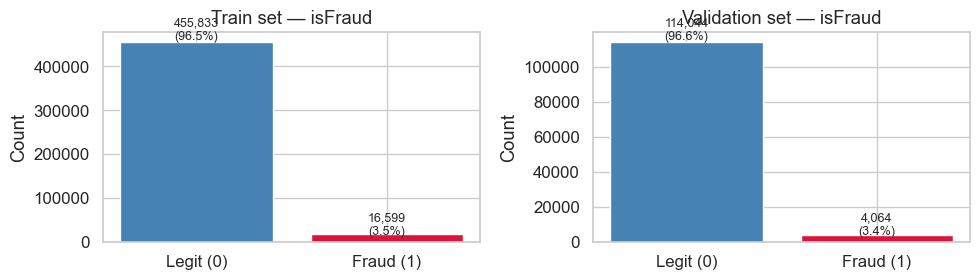

In [16]:
# Verify no time leakage
train_max = df_tree['TransactionDT'].iloc[:cutoff_idx].max()
val_min   = df_tree['TransactionDT'].iloc[cutoff_idx:].min()
assert val_min >= train_max, 'TIME LEAKAGE: validation starts before training ends'
print(f'Train DT max : {train_max}')
print(f'Val   DT min : {val_min}')
print('No time leakage.')

# Class balance in each split
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (label, y) in zip(axes, [('Train', y_train), ('Validation', y_val)]):
    counts = y.value_counts().sort_index()
    ax.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'crimson'])
    ax.set_title(f'{label} set — isFraud')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v * 1.01, f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. QC Summary & Persist Outputs

In [17]:
print('=' * 62)
print('CLEANING PIPELINE — QC SUMMARY')
print('=' * 62)
print(f'Source rows                     : {len(df):,} (unchanged)')
print(f'Columns pruned (NZV + dead)     : {len(DROP_COLS)}')
print(f'_isnan flags added              : {len(cols_to_flag)}')
print(f'Engineered features             : hour_of_day, day_of_week,')
print(f'                                  sin/cos_hour, sin/cos_dow,')
print(f'                                  has_identity, card1_txn_count,')
print(f'                                  card1_mean_amt')
print()
print('TREE BRANCH  (NaNs preserved for LightGBM/XGBoost)')
print(f'  X_train : {X_train_tree.shape}  NaN: {X_train_tree.isnull().sum().sum():,}')
print(f'  X_val   : {X_val_tree.shape}   NaN: {X_val_tree.isnull().sum().sum():,}')
print()
print('LINEAR BRANCH  (median-imputed, log1p(TransactionAmt))')
print(f'  X_train : {X_train_linear.shape}')
print(f'  X_val   : {X_val_linear.shape}')
print(f'  Residual NaN: {X_train_linear.isnull().sum().sum():,}  (must be 0)')
print()
print('TARGET')
print(f'  y_train fraud rate : {y_train.mean()*100:.2f}%')
print(f'  y_val   fraud rate : {y_val.mean()*100:.2f}%')
print('=' * 62)

CLEANING PIPELINE — QC SUMMARY
Source rows                     : 590,540 (unchanged)
Columns pruned (NZV + dead)     : 11
_isnan flags added              : 287
Engineered features             : hour_of_day, day_of_week,
                                  sin/cos_hour, sin/cos_dow,
                                  has_identity, card1_txn_count,
                                  card1_mean_amt

TREE BRANCH  (NaNs preserved for LightGBM/XGBoost)
  X_train : (472432, 712)  NaN: 79,747,049
  X_val   : (118108, 712)   NaN: 20,054,446

LINEAR BRANCH  (median-imputed, log1p(TransactionAmt))
  X_train : (472432, 770)
  X_val   : (118108, 770)
  Residual NaN: 0  (must be 0)

TARGET
  y_train fraud rate : 3.51%
  y_val   fraud rate : 3.44%


In [18]:
# Persist cleaned splits
X_train_tree.to_parquet(OUTPUT / 'X_train_tree.parquet',     index=False)
X_val_tree.to_parquet(  OUTPUT / 'X_val_tree.parquet',       index=False)
X_train_linear.to_parquet(OUTPUT / 'X_train_linear.parquet', index=False)
X_val_linear.to_parquet(  OUTPUT / 'X_val_linear.parquet',   index=False)
y_train.to_frame().to_parquet(OUTPUT / 'y_train.parquet',    index=False)
y_val.to_frame().to_parquet(  OUTPUT / 'y_val.parquet',      index=False)

# Pipeline metadata for reproducibility
meta = {
    'dropped_cols'           : DROP_COLS,
    'isnan_flag_cols'        : cols_to_flag,
    'feature_cols_tree'      : feat_tree,
    'feature_cols_linear'    : feat_linear,
    'cutoff_TransactionDT'   : cutoff_dt,
    'cutoff_row_index'       : cutoff_idx,
    'freq_maps'              : {k: {str(kk): float(vv) for kk, vv in v.items()}
                                for k, v in freq_maps.items()},
}
(OUTPUT / 'cleaning_meta.json').write_text(json.dumps(meta, indent=2))

print(f'Saved to {OUTPUT.resolve()}')
for f in sorted(OUTPUT.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:<40} {size_mb:>6.1f} MB')

Saved to D:\banking-risk-intelligence-rag\data\processed
  cleaning_meta.json                          0.1 MB
  X_train_linear.parquet                     72.1 MB
  X_train_tree.parquet                       83.6 MB
  X_val_linear.parquet                       18.9 MB
  X_val_tree.parquet                         21.8 MB
  y_train.parquet                             0.0 MB
  y_val.parquet                               0.0 MB
